# How to Access the Giovanni Area-Average Time Series Service Using Python

### Author: Chris Battisto
### Date Authored: 03-04-2024

### Timing

Exercise: 5 minutes

### Overview

This notebook demonstrates how to access the Cloud-enabled Giovanni Area-Average Time Series Service using Python. It contains steps checking the user's Giovanni quota before proceeding with searching and querying the area-average time series service via the harmony-py library, with the end goal of finding the most intense dust storm over the Atlantic ocean since 2000 from the [MERRA-2 M2T1NXAER](https://www.earthdata.nasa.gov/data/catalog/ges-disc-m2t1nxaer-5.12.4) collection.

### Prerequisites

This notebook was written using Python 3.11, and requires:
- Valid [Earthdata Login credentials](https://urs.earthdata.nasa.gov), and the generation of [Earthdata Prerequisite Files](https://disc.gsfc.nasa.gov/information/howto?title=How%20to%20Generate%20Earthdata%20Prerequisite%20Files) including the <code>.netrc</code> file.
- [Xarray](https://docs.xarray.dev/en/stable/)
- [Rioxarray](https://corteva.github.io/rioxarray/html/index.html)
- [NumPy <v2](https://numpy.org/)
- [Harmony-py](https://harmony-py.readthedocs.io/en/main/)
- [Matplotlib](https://matplotlib.org/)
- [Cartopy](https://scitools.org.uk/cartopy/docs/latest/)

### Optional Anaconda Environment YAML:

This notebook can be run using the ['nasa-gesdisc' YAML file](https://github.com/nasa/gesdisc-tutorials/tree/main/environments/nasa-gesdisc.yml) provided in the 'environments' subfolder. 
Please follow the instructions [here](https://conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html#creating-an-environment-from-an-environment-yml-file) to install and activate this environment.

In [ ]:
from harmony import Dimension, Client, Collection, Request, Environment,BBox
import datetime as dt
import os
import xarray as xr
import rioxarray
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import cartopy.crs as ccrs

## Use Dust Column Mass Density from M2T1NXAER v.5.12.4 (DUCMASS) to calculate a long area-averaged time series over the Atlantic

In [ ]:
%%time
harmony_client = Client()
collection = Collection(id="C1276812830-GES_DISC")
request = Request(
    collection=collection,
    temporal={"start": dt.datetime(2020, 1, 1,0,0,0), "stop": dt.datetime(2025,9, 1,0,0,0)},
    spatial=BBox(-60.4687,-10.418,12.6563,37.3945),
    variables=["M2T1NXAER_5_12_4_DUCMASS"],
    format="text/csv",
    average="area",
)

job_id = harmony_client.submit(request)
results = harmony_client.download_all(job_id)
for r in results:
    timeseries_fn = r.result()

## Parse the output csv file

In [ ]:
timeseries_attrs = {}
with open(timeseries_fn) as f:
    # Parse the header attributes until the line with just a comma
    done = False
    line = f.readline().strip()
    timeseries_attrs = {}
    while line != ",":
        attr, value = line.split(",", 1)
        timeseries_attrs[attr] = value
        line = f.readline().strip()
    # Parse the data
    timeseries_df = pd.read_csv(f, parse_dates=[0])

In [ ]:
timeseries_df.plot(x="time",y="mean_M2T1NXAER_5_12_4_DUCMASS")
plt.ylabel("kg m-2")
ax = plt.gca()
ax.get_legend().remove()
plt.title("Area-averaged time series of Dust Column Mass Density (DUCMASS, M2T1NXAER v5.12.4)\nover region [60.4687W,10.418S,12.6563E,37.3945N]");

## Just for kicks, look at how many time slices of data we pulled in this request:

In [ ]:
len(timeseries_df)

## Find where that tallest spike is in time

In [ ]:
storm_indexes = np.where(timeseries_df["mean_M2T1NXAER_5_12_4_DUCMASS"] > 0.0005)[0]
storm_start_date = timeseries_df["time"][storm_indexes[0]].to_pydatetime()
storm_end_date =timeseries_df["time"][storm_indexes[-1]].to_pydatetime()
storm_start_date, storm_end_date

## Now get a time-averaged map over that time and see what the storm looked like

In [ ]:
%%time
request = Request(
    collection=collection,
    temporal={"start": storm_start_date, "stop":storm_end_date},
    spatial=BBox(-60.4687,-10.418,12.6563,37.3945),
    variables=["M2T1NXAER_5_12_4_DUCMASS"],
    format="image/tiff",
    average="time",
)

job_id = harmony_client.submit(request)
results = harmony_client.download_all(job_id)
for r in results:
    map_fn = r.result()

## Parse the output geotiff and plot!

In [ ]:
tif_xds =  rioxarray.open_rasterio(map_fn, mask_and_scale=True)

In [ ]:
# Set the figure size, projection, extent and grid lines to the plot
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-90,60,-10,30])
ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=1, color='black', linestyle='--')
gl.right_labels = False
gl.top_labels = False

# Get the minimum and maximum values in the array
vmin = tif_xds.min()
vmax = tif_xds.max()

# Plot the time averaged map
tif_xds.plot(cbar_kwargs={"orientation": "horizontal", "pad": 0.05,"label":"kg m-2"}, 
             cmap="Oranges", vmin=vmin, vmax=vmax)
plt.title("Time average of Dust Column Mass Density (DUCMASS, M2T1NXAER v5.12.4)\nover 2020-06-16 15:30Z / 2020-06-20 23:30Z");

## So how long does on-prem Giovanni take to do that time series?
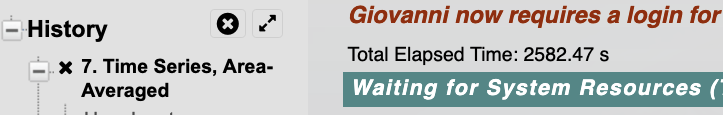

In [ ]:
# In minutes:
2582.27/60